# 02 · Energy Analysis ⭐

This is the core analysis notebook for the thesis. It provides a deep dive into CPU and
Memory energy consumption across 18 languages, grouped by execution paradigm (AOT, JIT,
Interpreted).

**Units:** All energy values are in **Joules (J)** (converted from raw µJ at load time).

**Key questions:**
- Which languages are most energy-efficient?
- Do paradigms (AOT vs JIT vs Interpreted) differ significantly in energy consumption?
- How does energy vary across benchmarks?

**Methodology:**
- Rankings, heatmaps and summary tables use the **two-step mean** (mean per
  language × benchmark, then averaged across the 8 benchmarks with equal weight),
  sourced from `results_clean.csv` via `lang_means()`.
- Significance testing keeps **non-parametric** tests, which are robust to the
  right-skewed, non-normal benchmark distributions:
  - **Kruskal-Wallis** (non-parametric ANOVA) for paradigm comparisons
  - **Mann-Whitney U** (pairwise) with **Bonferroni correction** for post-hoc tests
  - **Rank-biserial correlation** as the effect size measure
- Boxplots/violins are shown as distribution views (the box still shows the
  median/quartiles); they are ordered by the mean and the mean is marked (▲).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'figure.figsize': (12, 6)})

In [2]:
# ── Column names as they appear in results_clean_runs.csv ────────────────────
# Units already converted by notebooks/01_data_cleaning.ipynb
COL_CPU_ENERGY = 'cpu_energy_rapl_msr_component-package_0-j'
COL_MEM_ENERGY = 'memory_energy_rapl_msr_component-dram_0-j'
COL_TIME       = 'phase_time_syscall_system-system-ms'
COL_CPU_CARBON = 'cpu_carbon_rapl_msr_component-package_0-g'
COL_MEM_CARBON = 'memory_carbon_rapl_msr_component-dram_0-g'

ALPHA = 0.05

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = Path('outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}

PARADIGM = {
    'C': 'AOT', 'C++': 'AOT', 'C#': 'AOT', 'Dart': 'AOT', 'Go': 'AOT',
    'Haskell': 'AOT', 'Java': 'AOT', 'OCaml': 'AOT', 'Rust': 'AOT', 'Swift': 'AOT',
    'Erlang': 'JIT', 'F#': 'JIT', 'JavaScript': 'JIT', 'PHP': 'JIT', 'Ruby': 'JIT',
    'Lua': 'Interpreted', 'Perl': 'Interpreted', 'Python': 'Interpreted',
}

PARADIGM_COLORS = {'AOT': '#2980b9', 'JIT': '#e67e22', 'Interpreted': '#27ae60'}
PARADIGM_ORDER  = ['AOT', 'JIT', 'Interpreted']

# Marker style for the mean (▲) overlaid on boxplots/violins (showmeans=True).
MEANPROPS = dict(marker='^', markerfacecolor='white', markeredgecolor='black', markersize=6)

# Data pre-cleaned by notebooks/01_data_cleaning.ipynb:
#   - Outliers removed per (language × benchmark) group, IQR fence on CPU energy + time
#   - Units already converted (J, ms, g, MB, W)
#
# Single source: results_clean_runs.csv — per-run rows.
#   df       = all per-run rows, used for distribution views and non-parametric tests.
#   df_mean  = per-(language × benchmark) mean, computed here from df.
#              Rankings, heatmaps and summary tables use df_mean via lang_means().
df = pd.read_csv('../../results/results_clean_runs.csv')
df['language'] = df['language'].replace(LANG_DISPLAY)
df['paradigm'] = df['language'].map(PARADIGM)

_id_cols = {'run_id', 'measured_at', 'language', 'benchmark', 'paradigm'}
_metric_cols = [c for c in df.columns if c not in _id_cols]
df_mean = df.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()
df_mean['paradigm'] = df_mean['language'].map(PARADIGM)

# Energy-Delay Product from representative (mean) values per cell: lower is better.
# EDP = (CPU + Memory energy) × time, in J·ms.
df_mean['EDP'] = (df_mean[COL_CPU_ENERGY] + df_mean[COL_MEM_ENERGY]) * df_mean[COL_TIME]


def lang_means(cols):
    """Per-language two-step mean for column(s) `cols` (str or list): average the
    per-benchmark cell means with equal benchmark weight. Returns a Series for a
    single column or a DataFrame for a list. Derived from results_clean_runs.csv."""
    return df_mean.groupby('language')[cols].mean()


print(f"Runs shape: {df.shape} | Cell-means shape: {df_mean.shape}")
print(f"Languages ({df['language'].nunique()}): {sorted(df['language'].unique())}")
print(f"Benchmarks ({df['benchmark'].nunique()}): {sorted(df['benchmark'].unique())}")
print("Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W")
print("Rankings use the two-step mean (equal benchmark weight) via lang_means(); "
      "boxplots/violins and non-parametric tests use the per-run df.")
df_mean.head(3)

Runs shape: (1280, 17) | Cell-means shape: (144, 16)
Languages (18): ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
Benchmarks (8): ['binary-trees', 'fannkuch-redux', 'fasta', 'k-nucleotide', 'mandelbrot', 'n-body', 'regex-redux', 'spectral-norm']
Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W
Rankings use the two-step mean (equal benchmark weight) via lang_means(); boxplots/violins and non-parametric tests use the per-run df.


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. CPU Energy by Language

Boxplots sorted by **mean** CPU energy (J), with the mean marked (▲). Lower is better
(more energy-efficient). The box still shows the median/quartiles as a distribution
reference. Each paradigm group is shown separately to highlight within-group spread.

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/1531330428.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


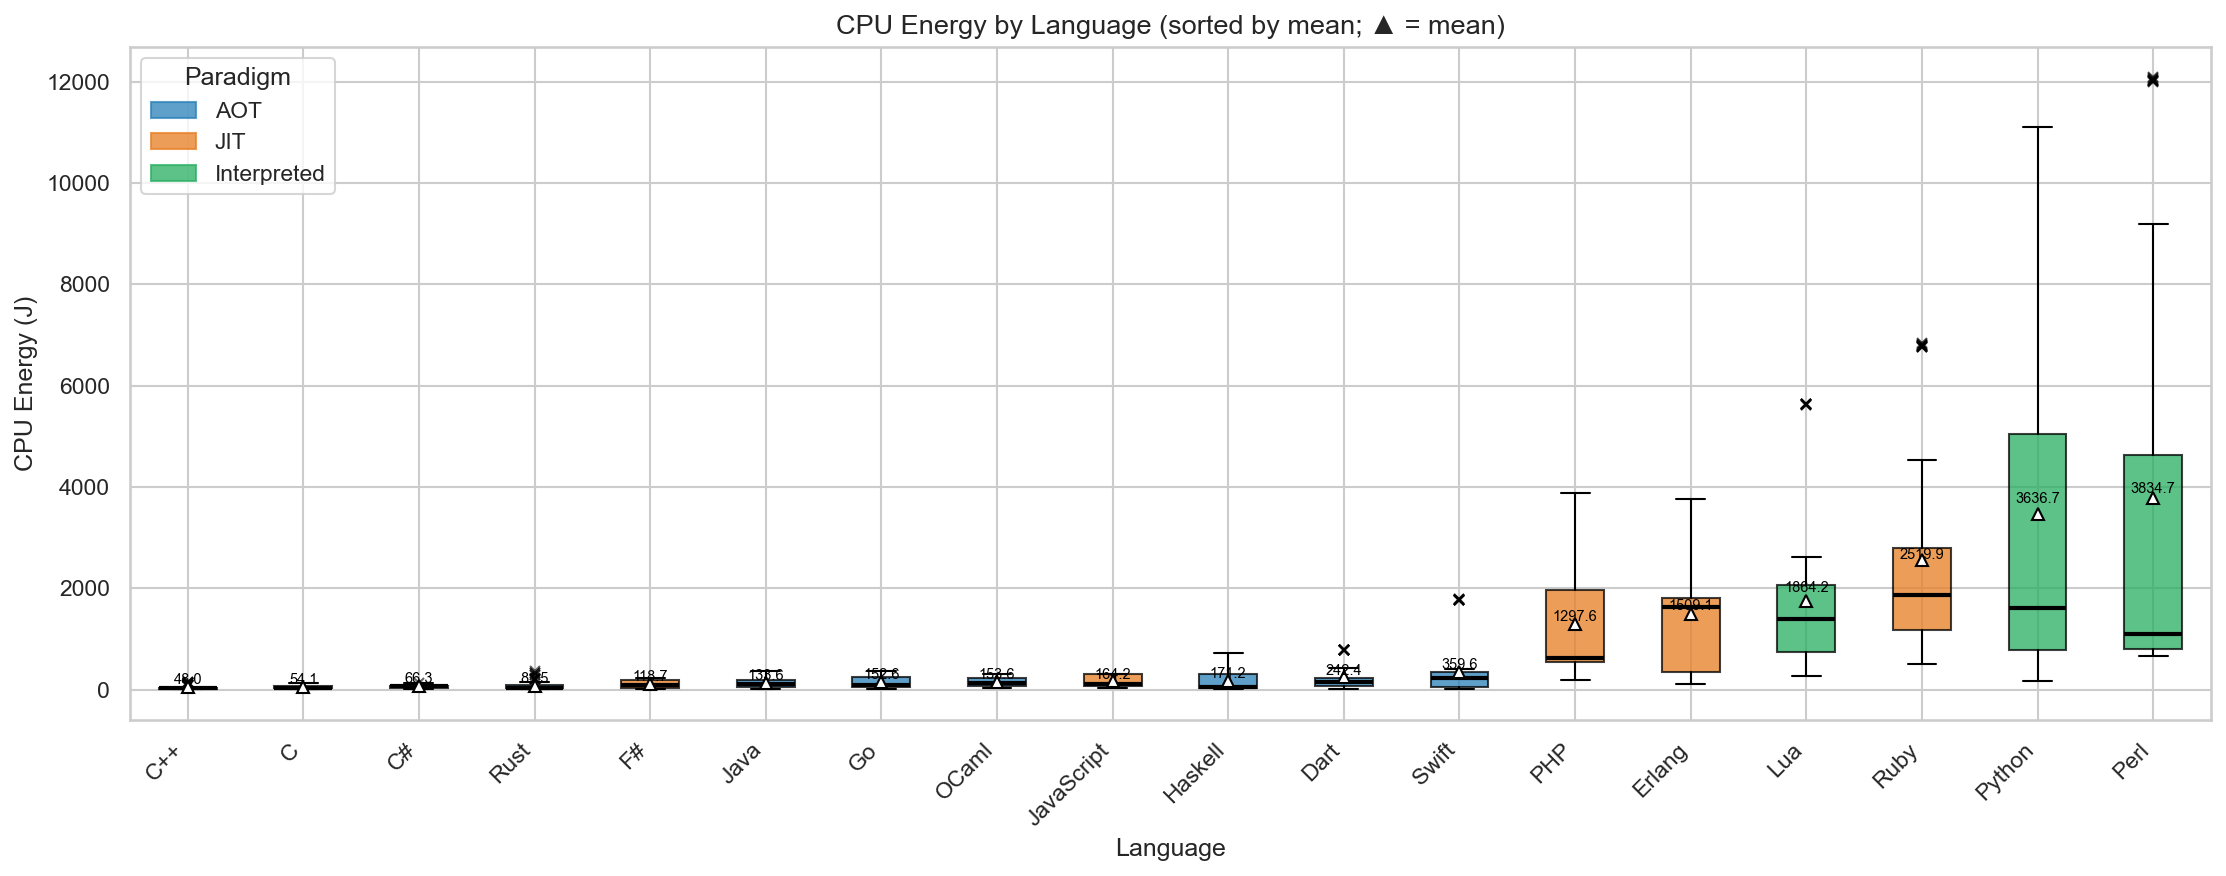

In [3]:
# Order and annotate by the two-step mean (equal benchmark weight); the boxplot
# itself is drawn from the per-run df to show the distribution.
cpu_mean = lang_means(COL_CPU_ENERGY)
lang_order_cpu = cpu_mean.sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(15, 6))
bp = ax.boxplot(
    [df[df['language'] == lang][COL_CPU_ENERGY].values for lang in lang_order_cpu],
    labels=lang_order_cpu, patch_artist=True, notch=False, showmeans=True, meanprops=MEANPROPS,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6),
)
for patch, lang in zip(bp['boxes'], lang_order_cpu):
    patch.set_facecolor(PARADIGM_COLORS[PARADIGM[lang]])
    patch.set_alpha(0.75)

for i, lang in enumerate(lang_order_cpu):
    m = cpu_mean[lang]
    ax.text(i + 1, m, f'{m:.1f}', ha='center', va='bottom', fontsize=7, color='black')

legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.75)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='upper left')
ax.set_title('CPU Energy by Language (sorted by mean; ▲ = mean)', fontsize=13)
ax.set_xlabel('Language')
ax.set_ylabel('CPU Energy (J)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cpu_energy_by_language.png', bbox_inches='tight')
plt.show()

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/349832087.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/349832087.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/349832087.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showm

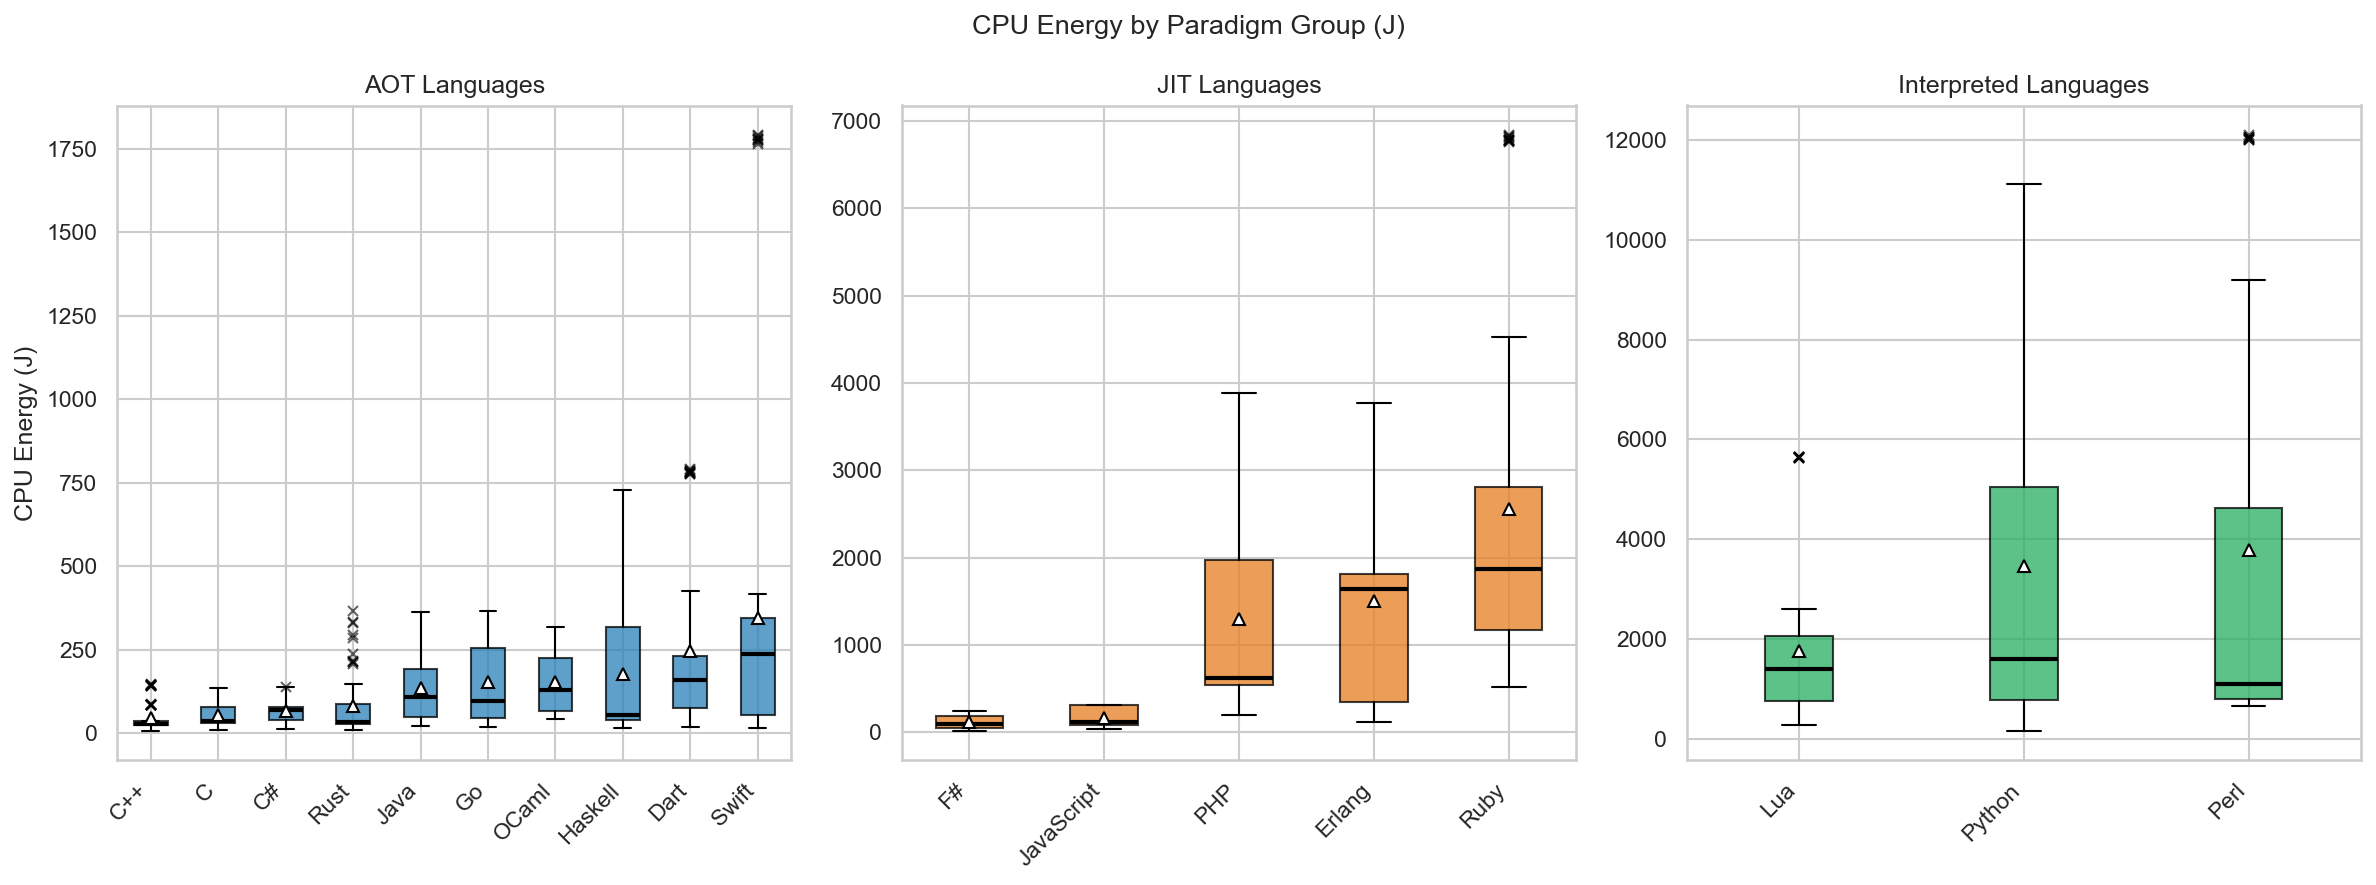

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, paradigm in zip(axes, PARADIGM_ORDER):
    langs = [l for l in lang_order_cpu if PARADIGM[l] == paradigm]
    data  = [df[df['language'] == l][COL_CPU_ENERGY].values for l in langs]
    bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6))
    for patch in bp['boxes']:
        patch.set_facecolor(PARADIGM_COLORS[paradigm])
        patch.set_alpha(0.75)
    ax.set_title(f'{paradigm} Languages')
    ax.set_ylabel('CPU Energy (J)' if paradigm == 'AOT' else '')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('CPU Energy by Paradigm Group (J)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cpu_energy_per_paradigm.png', bbox_inches='tight')
plt.show()

## 2. Memory Energy by Language

Same structure as CPU energy. Memory energy (J) reflects DRAM power draw, which varies
less across paradigms but reveals GC pressure and allocation patterns.

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/1618666324.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


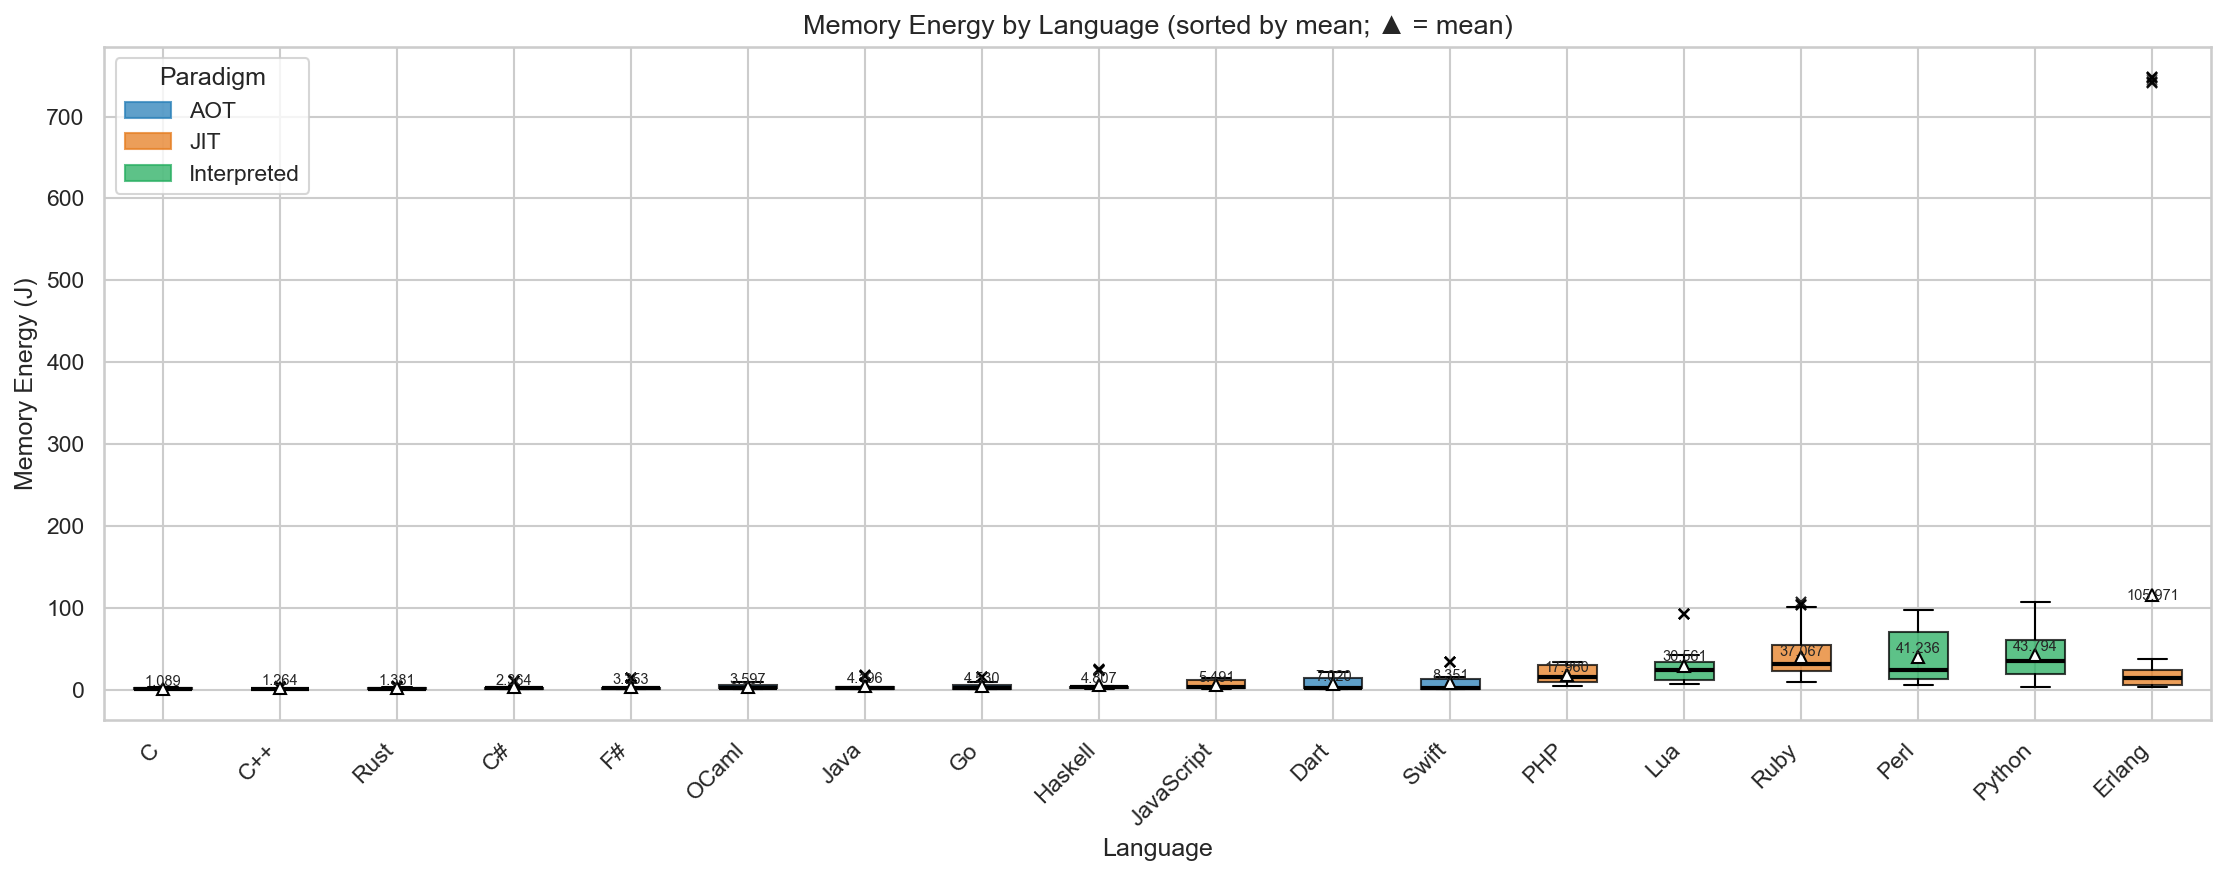

In [5]:
mem_mean = lang_means(COL_MEM_ENERGY)
lang_order_mem = mem_mean.sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(15, 6))
bp = ax.boxplot(
    [df[df['language'] == lang][COL_MEM_ENERGY].values for lang in lang_order_mem],
    labels=lang_order_mem, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6),
)
for patch, lang in zip(bp['boxes'], lang_order_mem):
    patch.set_facecolor(PARADIGM_COLORS[PARADIGM[lang]])
    patch.set_alpha(0.75)

for i, lang in enumerate(lang_order_mem):
    m = mem_mean[lang]
    ax.text(i + 1, m, f'{m:.3f}', ha='center', va='bottom', fontsize=7)

legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.75)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='upper left')
ax.set_title('Memory Energy by Language (sorted by mean; ▲ = mean)', fontsize=13)
ax.set_xlabel('Language')
ax.set_ylabel('Memory Energy (J)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mem_energy_by_language.png', bbox_inches='tight')
plt.show()

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/3432735155.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/3432735155.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/3432735155.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, sh

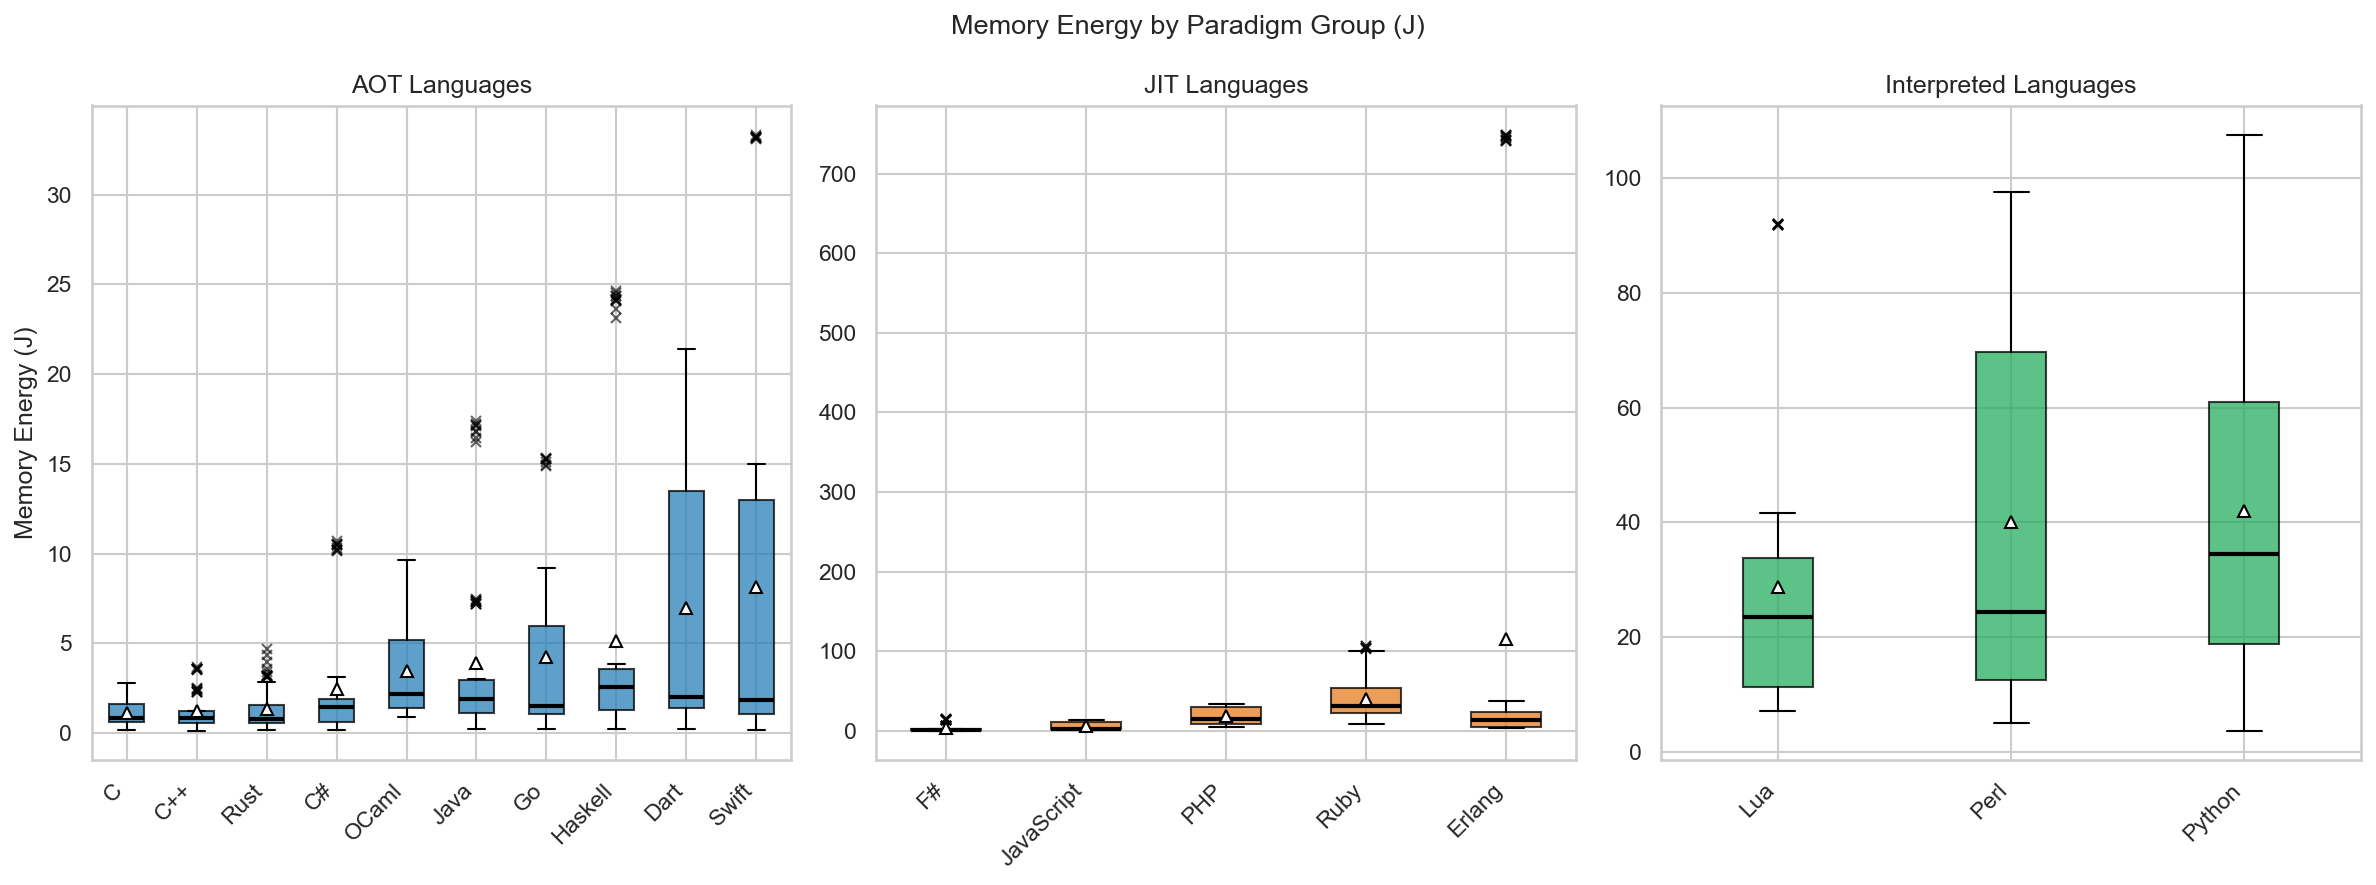

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, paradigm in zip(axes, PARADIGM_ORDER):
    langs = [l for l in lang_order_mem if PARADIGM[l] == paradigm]
    data  = [df[df['language'] == l][COL_MEM_ENERGY].values for l in langs]
    bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6))
    for patch in bp['boxes']:
        patch.set_facecolor(PARADIGM_COLORS[paradigm])
        patch.set_alpha(0.75)
    ax.set_title(f'{paradigm} Languages')
    ax.set_ylabel('Memory Energy (J)' if paradigm == 'AOT' else '')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Memory Energy by Paradigm Group (J)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mem_energy_per_paradigm.png', bbox_inches='tight')
plt.show()

## 3. CPU + Memory Energy Combined

Two complementary views:
1. **Stacked bar chart** — total energy (CPU + Memory) per language in Joules, split by component
2. **Scatter plot** — CPU vs Memory energy (J), to identify languages where one dominates

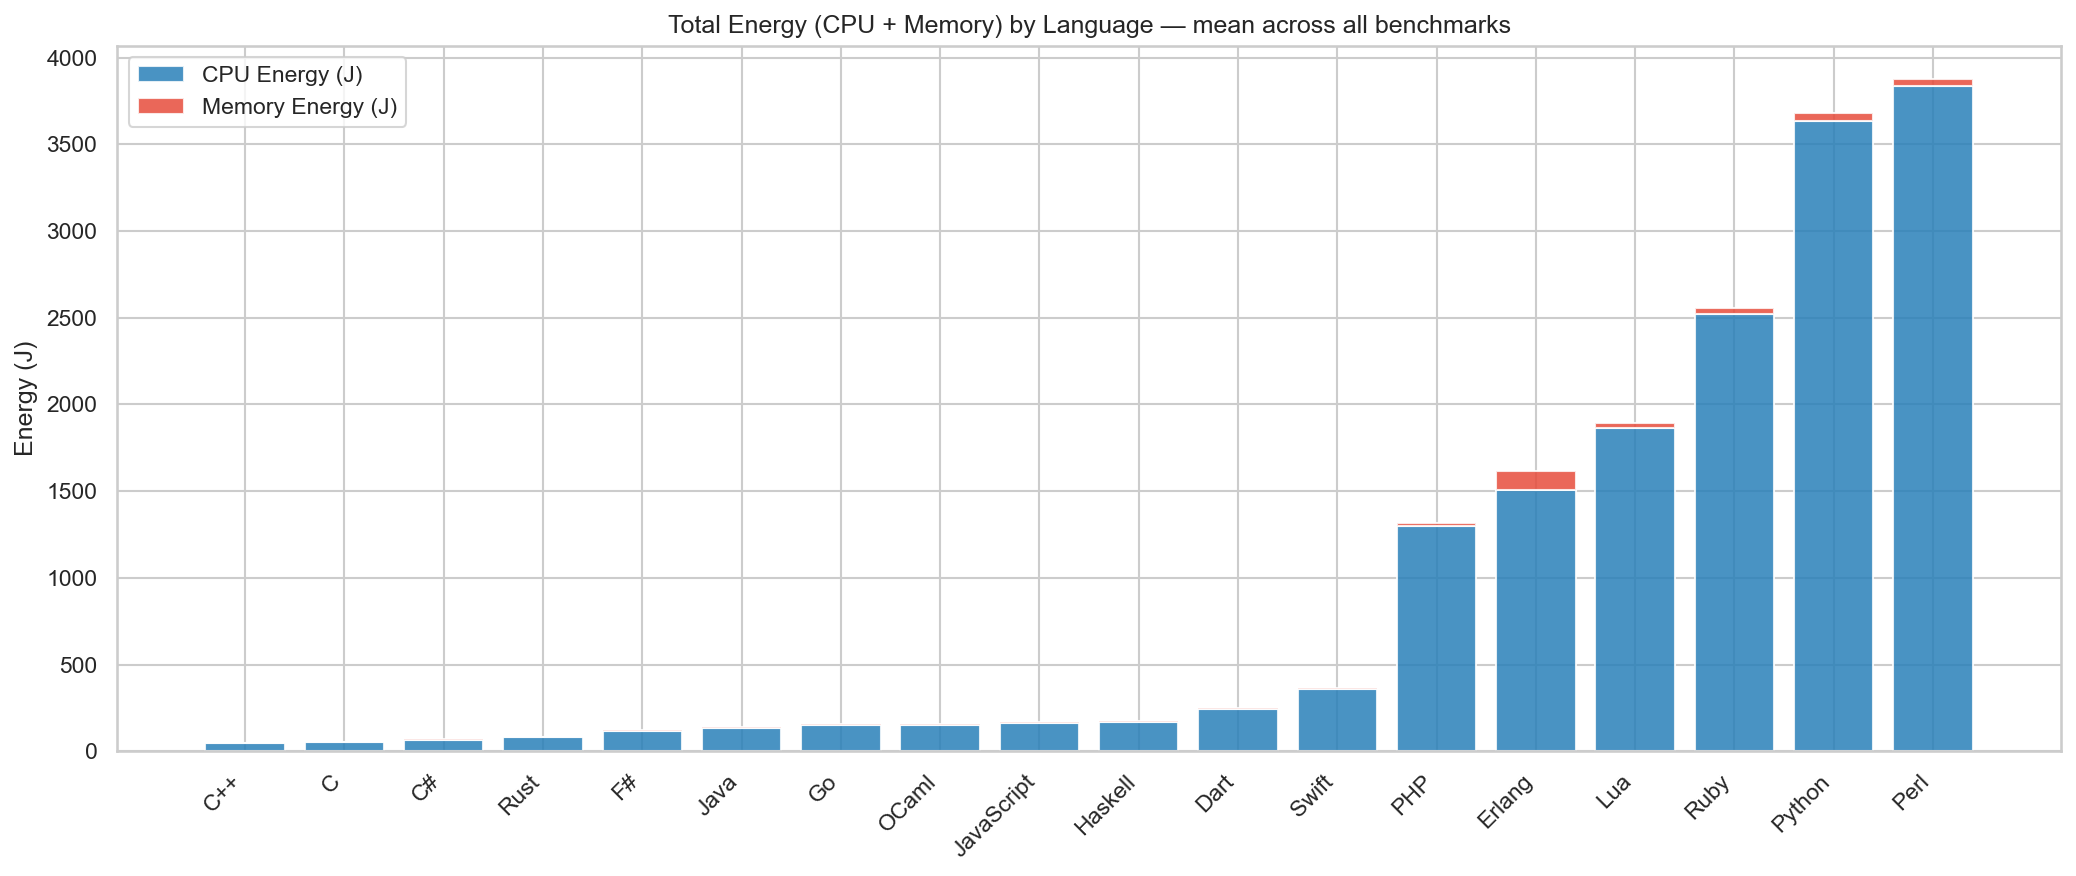

In [7]:
agg = lang_means([COL_CPU_ENERGY, COL_MEM_ENERGY])
agg = agg.sort_values(COL_CPU_ENERGY)
agg['paradigm'] = agg.index.map(PARADIGM)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(agg))
ax.bar(x, agg[COL_CPU_ENERGY], label='CPU Energy (J)', color='#2980b9', alpha=0.85)
ax.bar(x, agg[COL_MEM_ENERGY], bottom=agg[COL_CPU_ENERGY],
       label='Memory Energy (J)', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(agg.index, rotation=45, ha='right')
ax.set_title('Total Energy (CPU + Memory) by Language — mean across all benchmarks', fontsize=12)
ax.set_ylabel('Energy (J)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'total_energy_stacked.png', bbox_inches='tight')
plt.show()

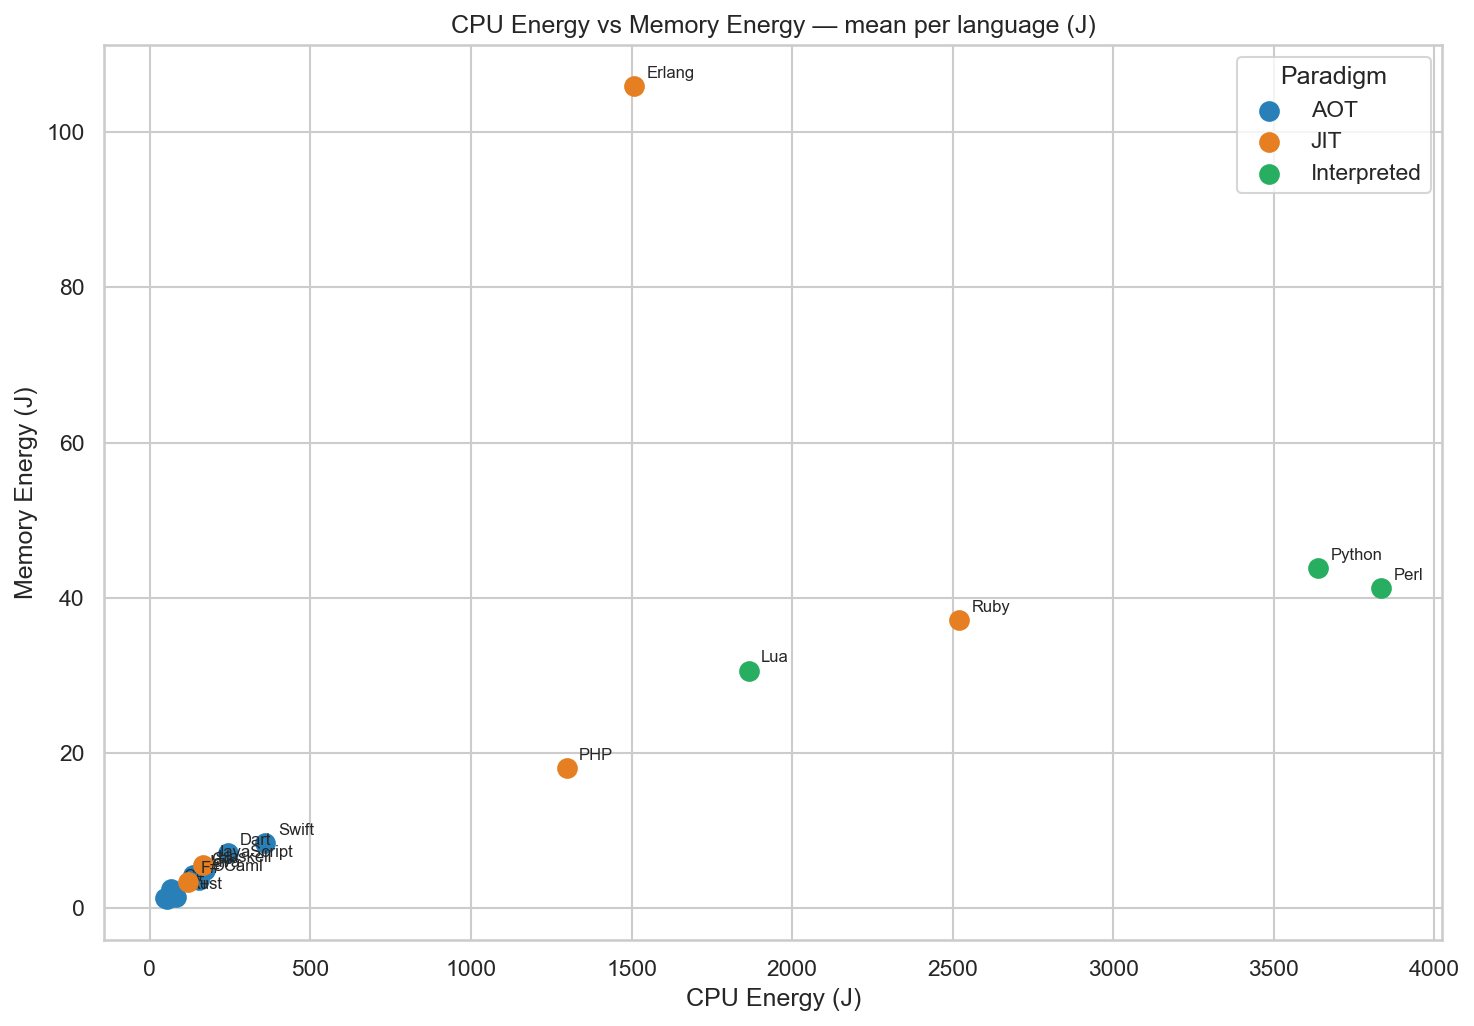

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
for paradigm in PARADIGM_ORDER:
    langs = [l for l in agg.index if agg.loc[l, 'paradigm'] == paradigm]
    ax.scatter(
        agg.loc[langs, COL_CPU_ENERGY],
        agg.loc[langs, COL_MEM_ENERGY],
        color=PARADIGM_COLORS[paradigm], label=paradigm, s=80, zorder=3
    )
    for lang in langs:
        ax.annotate(lang,
                    (agg.loc[lang, COL_CPU_ENERGY], agg.loc[lang, COL_MEM_ENERGY]),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_title('CPU Energy vs Memory Energy — mean per language (J)', fontsize=12)
ax.set_xlabel('CPU Energy (J)')
ax.set_ylabel('Memory Energy (J)')
ax.legend(title='Paradigm')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cpu_vs_mem_scatter.png', bbox_inches='tight')
plt.show()

## 4. Paradigm Comparison

**Violin plots** show the full distribution shape per paradigm.
**Kruskal-Wallis** tests whether any paradigm differs significantly.
If significant, **pairwise Mann-Whitney U** tests with **Bonferroni correction** identify which pairs differ.
Effect size is reported as **rank-biserial correlation** r = 1 − 2U/(n₁·n₂).

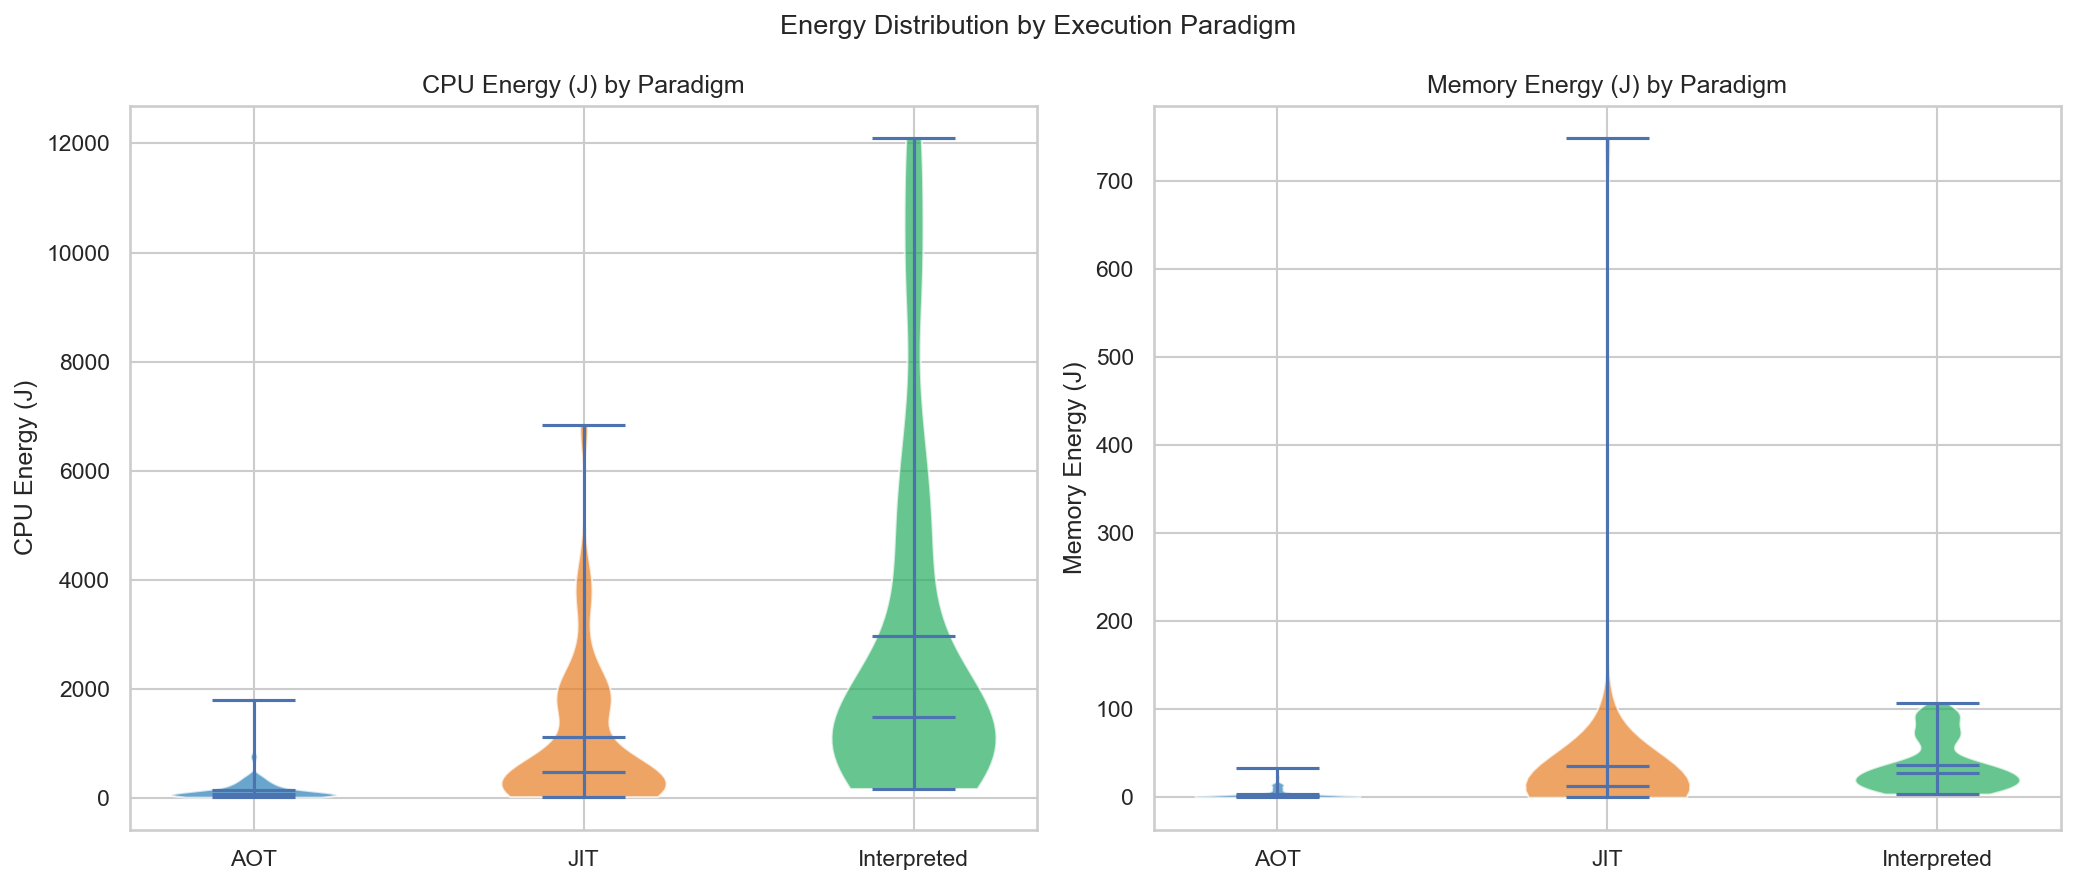

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, label in zip(axes,
                           [COL_CPU_ENERGY, COL_MEM_ENERGY],
                           ['CPU Energy (J)', 'Memory Energy (J)']):
    groups = [df[df['paradigm'] == p][col].values for p in PARADIGM_ORDER]
    parts  = ax.violinplot(groups, positions=range(len(PARADIGM_ORDER)), showmedians=True, showmeans=True)
    for pc, p in zip(parts['bodies'], PARADIGM_ORDER):
        pc.set_facecolor(PARADIGM_COLORS[p])
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(PARADIGM_ORDER)))
    ax.set_xticklabels(PARADIGM_ORDER)
    ax.set_title(f'{label} by Paradigm')
    ax.set_ylabel(label)

fig.suptitle('Energy Distribution by Execution Paradigm', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'energy_violin_paradigm.png', bbox_inches='tight')
plt.show()

In [10]:
def rank_biserial(x, y):
    """Rank-biserial correlation as effect size for Mann-Whitney U."""
    u, _ = stats.mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * u) / (len(x) * len(y))

for col, label in [(COL_CPU_ENERGY, 'CPU Energy (J)'), (COL_MEM_ENERGY, 'Memory Energy (J)')]:
    groups   = {p: df[df['paradigm'] == p][col].values for p in PARADIGM_ORDER}
    kw_stat, kw_p = stats.kruskal(*groups.values())
    n_pairs = len(PARADIGM_ORDER) * (len(PARADIGM_ORDER) - 1) // 2

    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"  Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.4f} ", end='')
    print("(SIGNIFICANT)" if kw_p < ALPHA else "(not significant)")

    if kw_p < ALPHA:
        print(f"  Post-hoc Mann-Whitney U (Bonferroni α={ALPHA/n_pairs:.4f}):")
        for (p1, p2) in combinations(PARADIGM_ORDER, 2):
            u, p = stats.mannwhitneyu(groups[p1], groups[p2], alternative='two-sided')
            p_adj = min(p * n_pairs, 1.0)
            r = rank_biserial(groups[p1], groups[p2])
            sig = "✓" if p_adj < ALPHA else "✗"
            print(f"    {sig} {p1} vs {p2}: U={u:.0f}, p_adj={p_adj:.4f}, r={r:.3f}")


CPU Energy (J)
  Kruskal-Wallis H=586.229, p=0.0000 (SIGNIFICANT)
  Post-hoc Mann-Whitney U (Bonferroni α=0.0167):
    ✓ AOT vs JIT: U=47849, p_adj=0.0000, r=0.627
    ✓ AOT vs Interpreted: U=4001, p_adj=0.0000, r=0.946
    ✓ JIT vs Interpreted: U=19265, p_adj=0.0000, r=0.489

Memory Energy (J)
  Kruskal-Wallis H=514.051, p=0.0000 (SIGNIFICANT)
  Post-hoc Mann-Whitney U (Bonferroni α=0.0167):
    ✓ AOT vs JIT: U=56326, p_adj=0.0000, r=0.560
    ✓ AOT vs Interpreted: U=7002, p_adj=0.0000, r=0.906
    ✓ JIT vs Interpreted: U=19214, p_adj=0.0000, r=0.491


## 5. Per-Benchmark Energy Heatmap

Heatmap of mean CPU and Memory energy (J) for each language × benchmark combination
(the per-cell means stored in `results_clean.csv`). This reveals which benchmarks are
most energy-intensive and which languages suffer disproportionately on specific workloads.

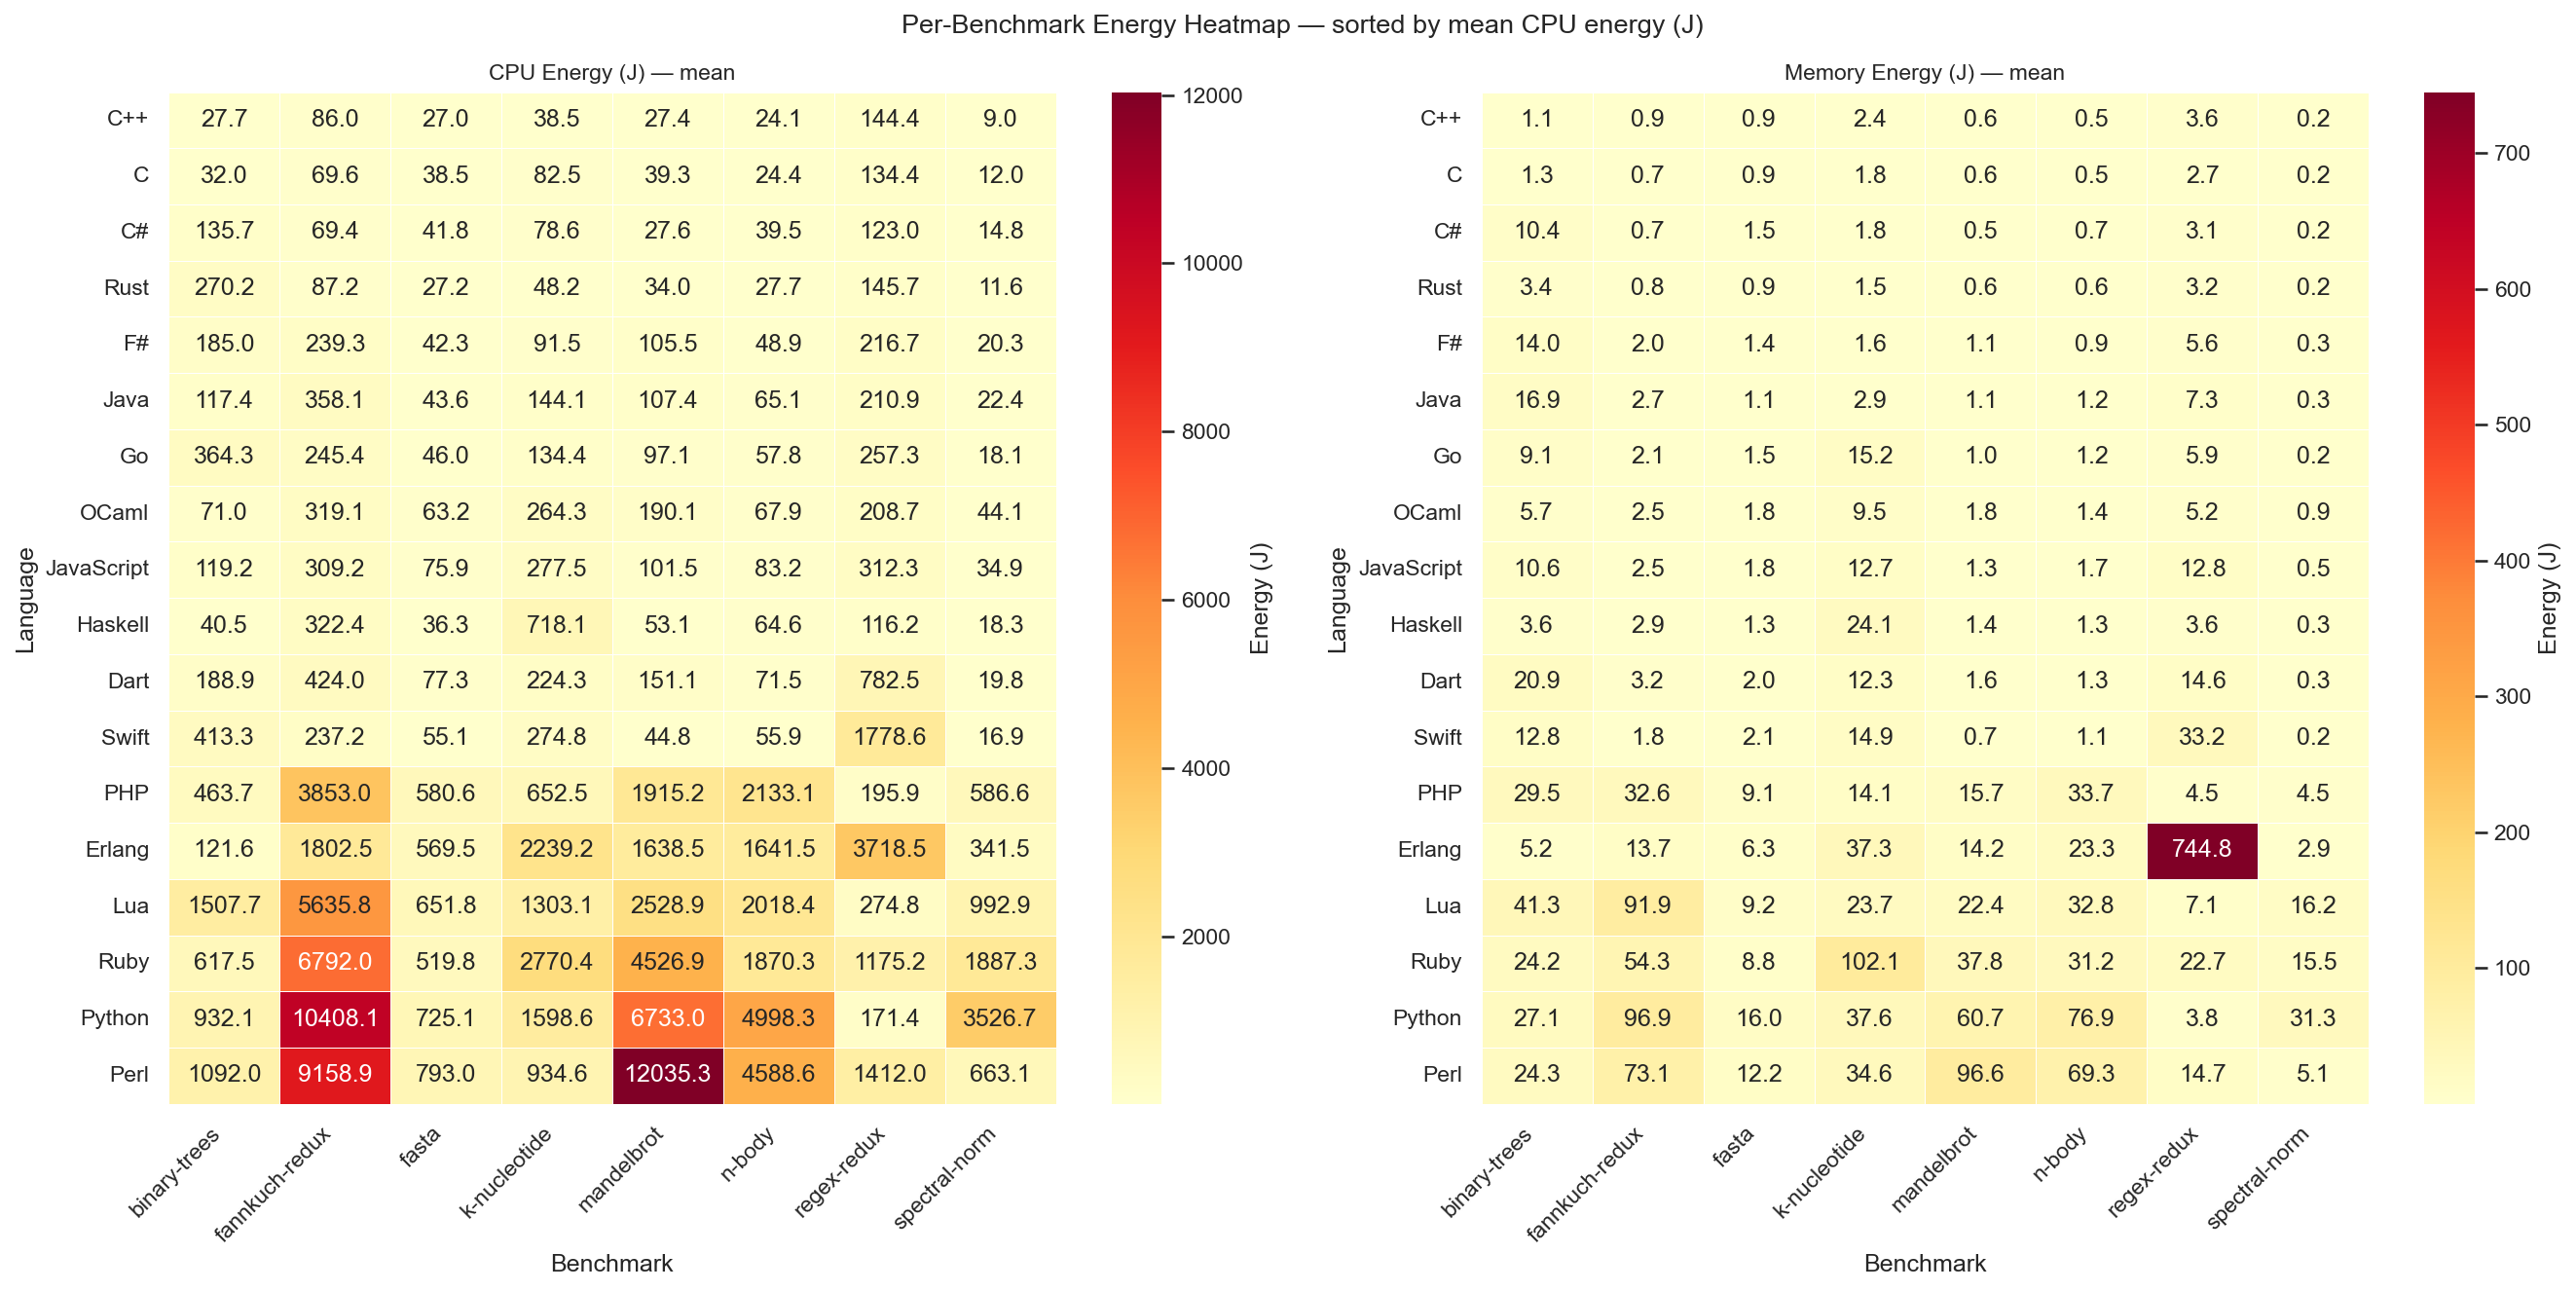

In [11]:
# Per-cell means come directly from df_mean (results_clean.csv).
pivot_cpu = df_mean.pivot(index='language', columns='benchmark', values=COL_CPU_ENERGY)
pivot_mem = df_mean.pivot(index='language', columns='benchmark', values=COL_MEM_ENERGY)

lang_sort = lang_means(COL_CPU_ENERGY).sort_values().index
pivot_cpu = pivot_cpu.loc[lang_sort]
pivot_mem = pivot_mem.loc[lang_sort]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, pivot, title in zip(axes,
                              [pivot_cpu, pivot_mem],
                              ['CPU Energy (J) — mean', 'Memory Energy (J) — mean']):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                linewidths=0.3, cbar_kws={'label': 'Energy (J)'})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Language')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Per-Benchmark Energy Heatmap — sorted by mean CPU energy (J)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'energy_heatmap_benchmark.png', bbox_inches='tight')
plt.show()

## 6. Energy Efficiency Ranking

Languages ranked by **mean** CPU energy (J) ascending (two-step mean, equal benchmark
weight) — lower rank = more efficient. A combined rank averages CPU and Memory ranks.

In [12]:
rank_agg = lang_means([COL_CPU_ENERGY, COL_MEM_ENERGY]).copy()
rank_agg.columns = ['cpu_mean_J', 'mem_mean_J']
rank_agg.insert(0, 'paradigm', rank_agg.index.map(PARADIGM))
rank_agg['cpu_rank'] = rank_agg['cpu_mean_J'].rank().astype(int)
rank_agg['mem_rank'] = rank_agg['mem_mean_J'].rank().astype(int)
rank_agg['combined_rank'] = ((rank_agg['cpu_rank'] + rank_agg['mem_rank']) / 2).round(1)
ranking = rank_agg.sort_values('combined_rank')
ranking.index.name = 'Language'
ranking[['paradigm', 'cpu_mean_J', 'mem_mean_J', 'cpu_rank', 'mem_rank', 'combined_rank']]

,paradigm,cpu_mean_J,mem_mean_J,cpu_rank,mem_rank,combined_rank
Language,,,,,,
C,AOT,54.080750,1.089060,2,1,1.5
C++,AOT,48.005385,1.264324,1,2,1.5
C#,AOT,66.300963,2.363736,3,4,3.5
Rust,AOT,81.467476,1.381183,4,3,3.5
F#,JIT,118.683036,3.353017,5,5,5.0
Java,AOT,133.624399,4.195979,6,7,6.5
OCaml,AOT,153.550146,3.596609,8,6,7.0
Go,AOT,152.565146,4.530067,7,8,7.5
Haskell,AOT,171.194480,4.807307,10,9,9.5


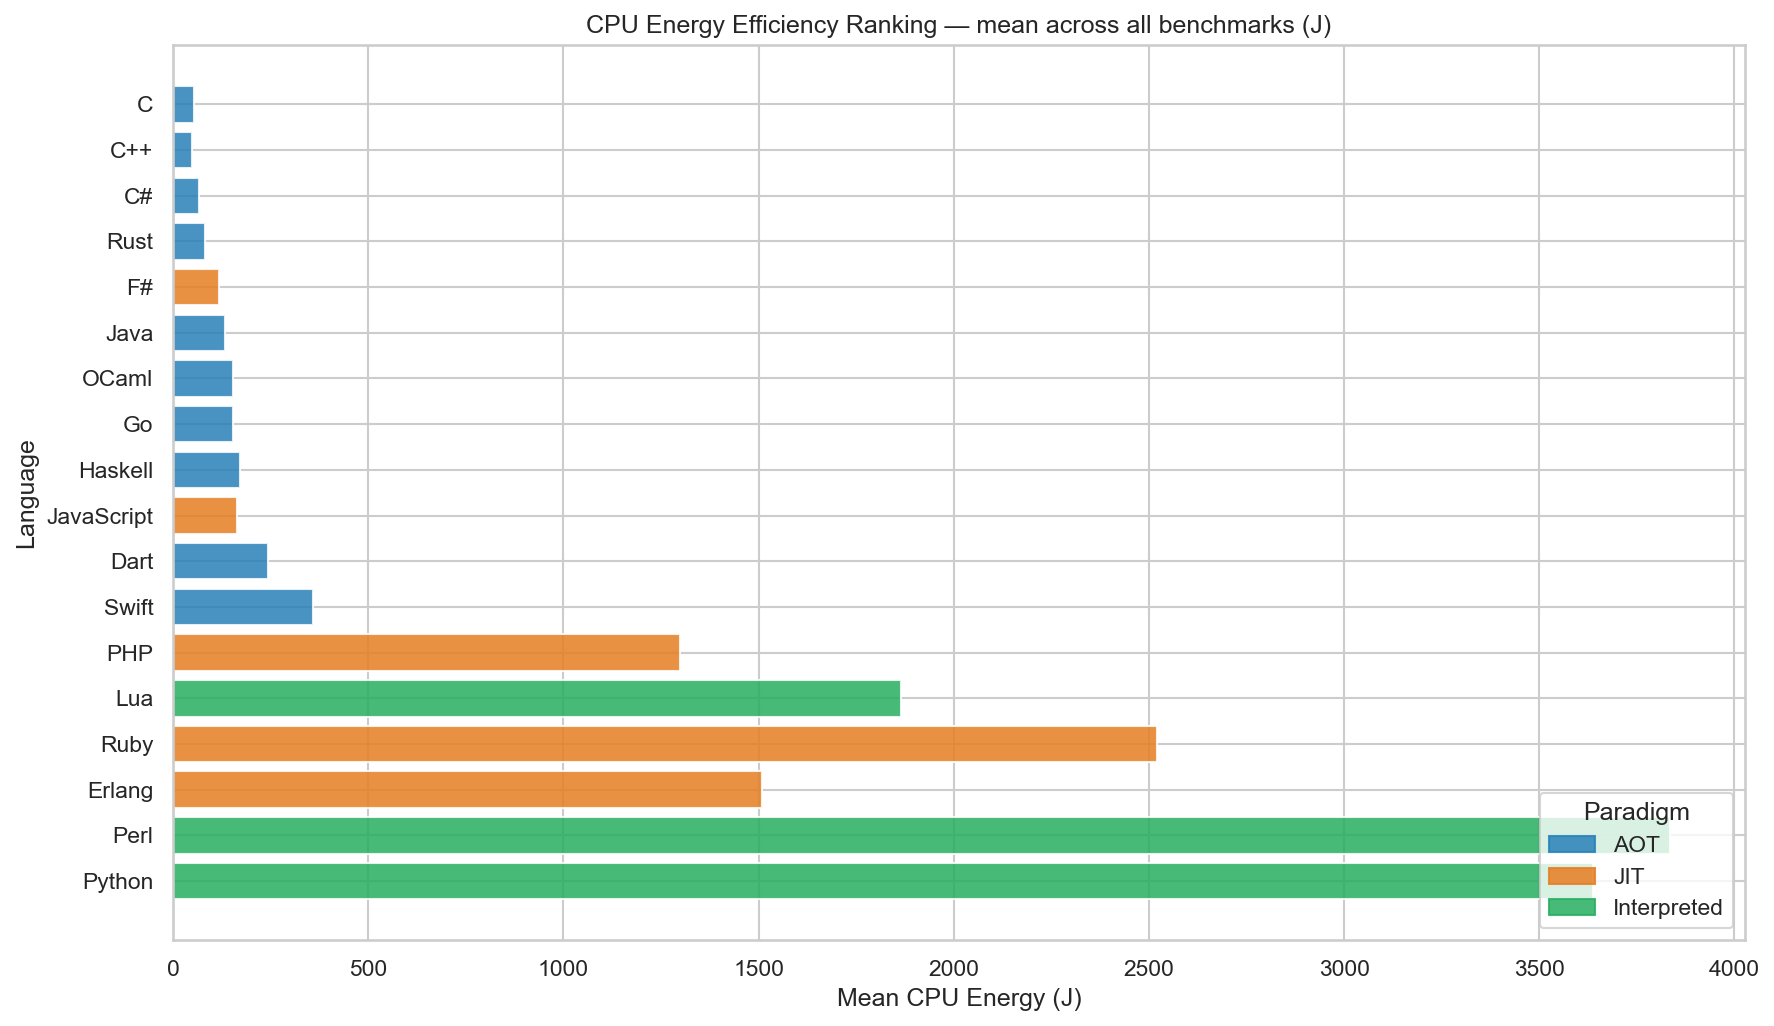

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = [PARADIGM_COLORS[PARADIGM[l]] for l in ranking.index]
ax.barh(ranking.index, ranking['cpu_mean_J'], color=colors, alpha=0.85, edgecolor='white')
ax.set_title('CPU Energy Efficiency Ranking — mean across all benchmarks (J)', fontsize=12)
ax.set_xlabel('Mean CPU Energy (J)')
ax.set_ylabel('Language')
ax.invert_yaxis()
legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.85)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cpu_energy_ranking.png', bbox_inches='tight')
plt.show()

## 7. CO₂ Carbon Correlation

CPU carbon (g CO₂) is derived from CPU energy via a carbon-intensity factor.
We verify the correlation and check whether it is simply proportional or shows variance.
Values are in grams (g) — converted from raw µg at load time.

Non-zero CPU carbon values: 100.0%
Spearman r(CPU energy J, CPU carbon g) = 1.0000, p = 0.00e+00


/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/2541413565.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58170/2541413565.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / 'cpu_energy_vs_carbon.png', bbox_inches='tight')
/Users/brandao/mthesis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


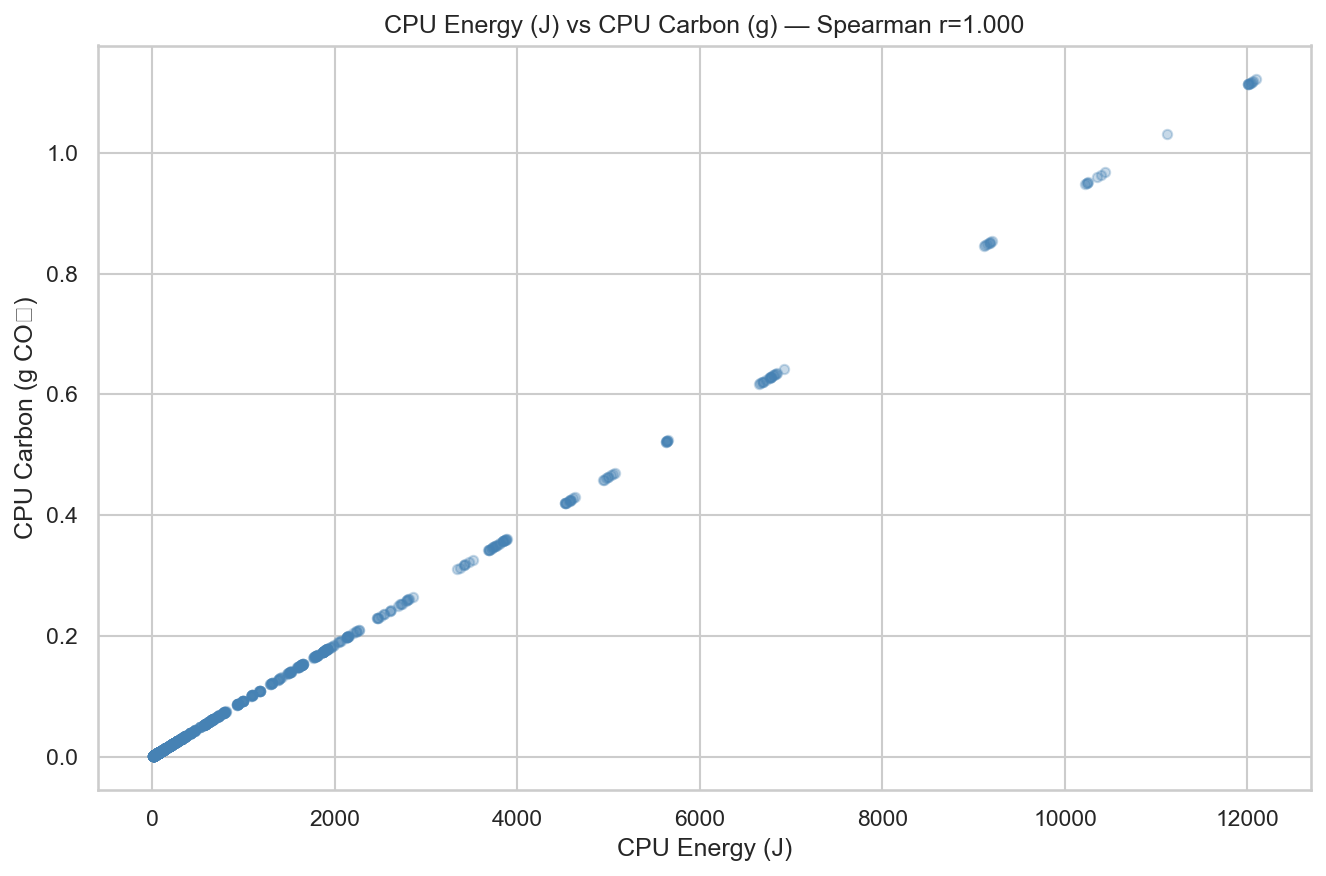

In [14]:
cpu_carbon_nonzero = (df[COL_CPU_CARBON] != 0).mean()
print(f"Non-zero CPU carbon values: {cpu_carbon_nonzero:.1%}")

if cpu_carbon_nonzero > 0.5:
    spearman_r, spearman_p = stats.spearmanr(df[COL_CPU_ENERGY], df[COL_CPU_CARBON])
    print(f"Spearman r(CPU energy J, CPU carbon g) = {spearman_r:.4f}, p = {spearman_p:.2e}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(df[COL_CPU_ENERGY], df[COL_CPU_CARBON], alpha=0.3, s=20, color='steelblue')
    ax.set_xlabel('CPU Energy (J)')
    ax.set_ylabel('CPU Carbon (g CO₂)')
    ax.set_title(f'CPU Energy (J) vs CPU Carbon (g) — Spearman r={spearman_r:.3f}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'cpu_energy_vs_carbon.png', bbox_inches='tight')
    plt.show()
else:
    print("CPU carbon column is mostly zero — likely not recorded for this dataset.")